In [1]:
!pip install -q monai gradio torch nibabel matplotlib tqdm

In [2]:
import os
from monai.apps import DecathlonDataset

# Create root directory automatically if it does not exist
root_dir = "./data"
os.makedirs(root_dir, exist_ok=True)

# Load the Spleen Decathlon Dataset
dataset = DecathlonDataset(
    root_dir=root_dir,
    task="Task09_Spleen",
    section="training",
    download=True,
)

2026-09-11 17:41:48,646 - INFO - Verified 'Task09_Spleen.tar', md5: 410d4a301da4e5b2f6f86ec3ddba524e.
2026-09-11 17:41:48,647 - INFO - File exists: data/Task09_Spleen.tar, skipped downloading.
2026-09-11 17:41:48,649 - INFO - Non-empty folder exists in data/Task09_Spleen, skipped extracting.


Loading dataset: 100%|██████████| 33/33 [00:45<00:00,  1.36s/it]


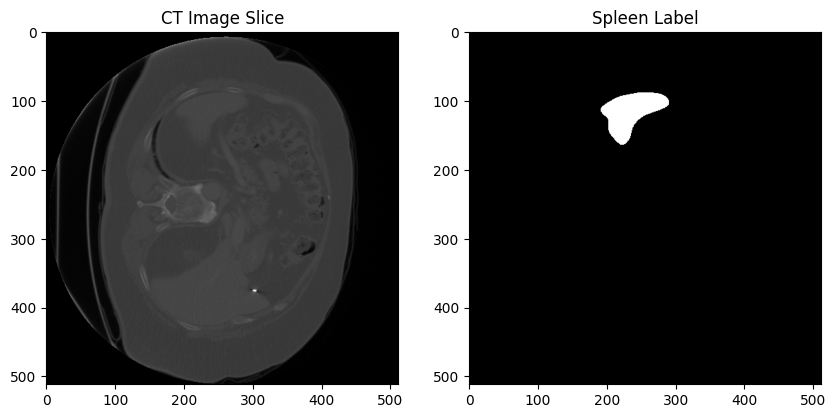

In [3]:
import matplotlib.pyplot as plt

# Fetch the first sample from the dataset
sample = dataset[0]
image = sample["image"]
label = sample["label"]

# Select the middle slice along the 3rd axis (Depth)
slice_idx = image.shape[2] // 2

plt.figure(figsize=(10, 5))

# Plot CT image slice
plt.subplot(1, 2, 1)
plt.title("CT Image Slice")
plt.imshow(image[:, :, slice_idx], cmap="gray")

# Plot segmentation label mask
plt.subplot(1, 2, 2)
plt.title("Spleen Label")
plt.imshow(label[:, :, slice_idx], cmap="gray")

plt.show()

Opening file: lihc__TCGA-BC-A10W__1992-11-13__VEN.nii.gz


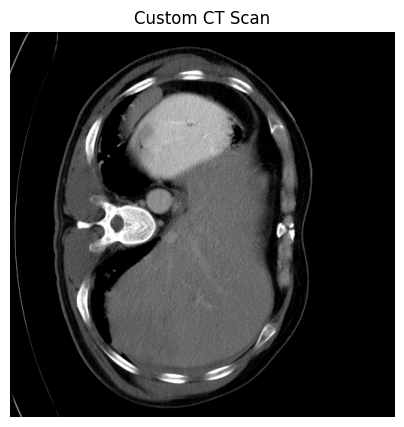

In [4]:
import os
import matplotlib.pyplot as plt
import nibabel as nib

# Search automatically for files starting with 'lihc' in the current directory
matching_files = [f for f in os.listdir(".") if f.startswith("lihc")]

if matching_files:
    file_path = matching_files[0]
    print(f"Opening file: {file_path}")

    # Load 3D image volume and extract middle slice
    custom_ct = nib.load(file_path).get_fdata()
    slice_idx = custom_ct.shape[2] // 2

    plt.figure(figsize=(5, 5))
    plt.imshow(custom_ct[:, :, slice_idx], cmap="gray")
    plt.title("Custom CT Scan")
    plt.axis("off")
    plt.show()
else:
    print("File not found. Please ensure it is uploaded to the left sidebar.")